# LegalEagle — LangChain RAG Pipeline for Contract Analysis

**Notebook 2 of the LegalEagle project.**

This notebook implements a full **Retrieval-Augmented Generation (RAG)** pipeline for legal contracts:

1. **Ingest** contracts from PDF / DOCX files using `PyPDFLoader` and `Docx2txtLoader`
2. **Chunk** the text using `RecursiveCharacterTextSplitter` (chunk_size=512, overlap=50)
3. **Embed** chunks using `sentence-transformers/all-MiniLM-L6-v2`
4. **Store** vectors in **ChromaDB** (local persistent vector store)
5. **Retrieve** relevant chunks for any legal query

> **Tech stack:** LangChain · ChromaDB · Sentence-Transformers · HuggingFace

## 0 — Imports & Setup

In [1]:
import os
import re
import warnings
import textwrap
import json
from pathlib import Path

warnings.filterwarnings('ignore')

# LangChain loaders
from langchain_community.document_loaders import PyPDFLoader, Docx2txtLoader, TextLoader
from langchain_core.documents import Document

# Splitter
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Embeddings
from langchain_huggingface import HuggingFaceEmbeddings

# Vector store
from langchain_chroma import Chroma

# Dataset (to get real contract text)
from datasets import load_from_disk

print('All imports successful!')

All imports successful!


## 1 — Prepare Sample Contract Files

Since we skipped downloading the raw PDFs (to avoid Windows path errors), we export **real contract text** from the CUAD dataset into `.txt` files. These act as our *ingested documents* for the pipeline.

In a real project you would simply point the loaders at your folder of PDFs/DOCX files.

In [2]:
# Load from disk
raw = load_from_disk('../data/cuad')
contracts = raw['train'][0]['data']
print(f'Loaded {len(contracts)} contracts from CUAD dataset')

# Create sample_contracts directory
contracts_dir = Path('../data/sample_contracts')
contracts_dir.mkdir(parents=True, exist_ok=True)

# Export first 10 contracts as .txt files (they simulate real ingested documents)
exported = []
for contract in contracts[:10]:
    title = re.sub(r'[^\w\-]', '_', contract['title'])[:60]
    full_text = '\n\n'.join(
        para['context'] for para in contract['paragraphs']
    )
    fpath = contracts_dir / f'{title}.txt'
    fpath.write_text(full_text, encoding='utf-8')
    exported.append(fpath)
    print(f'  Exported: {fpath.name}  ({len(full_text):,} chars)')

print(f'\nTotal contracts exported: {len(exported)}')

Loaded 510 contracts from CUAD dataset
  Exported: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR_AGREEMENT.txt  (54,290 chars)
  Exported: WHITESMOKE_INC_11_08_2011-EX-10_26-PROMOTION_AND_DISTRIBUTIO.txt  (70,383 chars)
  Exported: LohaCompanyltd_20191209_F-1_EX-10_16_11917878_EX-10_16_Suppl.txt  (11,475 chars)
  Exported: CENTRACKINTERNATIONALINC_10_29_1999-EX-10_3-WEB_SITE_HOSTING.txt  (15,176 chars)
  Exported: NELNETINC_04_08_2020-EX-1-JOINT_FILING_AGREEMENT.txt  (1,081 chars)
  Exported: ADAMSGOLFINC_03_21_2005-EX-10_17-ENDORSEMENT_AGREEMENT.txt  (24,632 chars)
  Exported: KIROMICBIOPHARMA_INC_05_11_2020-EX-10_23-CONSULTING_AGREEMEN.txt  (18,403 chars)
  Exported: VEONEER_INC_02_21_2020-EX-10_11-JOINT_VENTURE_AGREEMENT.txt  (8,257 chars)
  Exported: DovaPharmaceuticalsInc_20181108_10-Q_EX-10_2_11414857_EX-10_.txt  (175,580 chars)
  Exported: PACIRA_PHARMACEUTICALS__INC__-_A_R_STRATEGIC_LICENSING__DIST.txt  (145,168 chars)

Total contracts exported: 10


## 2 — Document Loader Pipeline

LangChain provides unified loaders for different file types:

| Loader | File type | Use case |
|---|---|---|
| `PyPDFLoader` | `.pdf` | Standard legal PDF contracts |
| `Docx2txtLoader` | `.docx` | Microsoft Word contracts |
| `TextLoader` | `.txt` | Plain text / OCR output |

All loaders return a list of `Document` objects — each has:
- `page_content` — the raw text
- `metadata` — source file, page number, etc.

We build a **unified loader** that auto-detects file type.

In [3]:
def load_document(file_path: str) -> list[Document]:
    """Load any PDF, DOCX, or TXT file and return LangChain Documents."""
    ext = Path(file_path).suffix.lower()
    if ext == '.pdf':
        loader = PyPDFLoader(file_path)
    elif ext in ('.docx', '.doc'):
        loader = Docx2txtLoader(file_path)
    else:  # .txt, .text, etc.
        loader = TextLoader(file_path, encoding='utf-8')
    return loader.load()


def load_all_contracts(folder: Path) -> list[Document]:
    """Walk a directory and load all supported contract files."""
    all_docs = []
    for fpath in sorted(folder.iterdir()):
        if fpath.suffix.lower() not in ('.pdf', '.docx', '.doc', '.txt'):
            continue
        try:
            docs = load_document(str(fpath))
            # Attach the filename into metadata
            for doc in docs:
                doc.metadata['source_file'] = fpath.name
                doc.metadata['contract_title'] = fpath.stem
            all_docs.extend(docs)
        except Exception as e:
            print(f'  [WARN] Could not load {fpath.name}: {e}')
    return all_docs


# Run the loader
print('Loading contracts...')
raw_documents = load_all_contracts(contracts_dir)
print(f'\nTotal documents loaded : {len(raw_documents)}')
print(f'Total characters      : {sum(len(d.page_content) for d in raw_documents):,}')

# Inspect one document
sample = raw_documents[0]
print(f'\n--- Sample Document ---')
print(f'Source : {sample.metadata["source_file"]}')
print(f'Length : {len(sample.page_content):,} chars')
print(f'Preview: {sample.page_content[:300]}...')

Loading contracts...

Total documents loaded : 10
Total characters      : 524,445

--- Sample Document ---
Source : ADAMSGOLFINC_03_21_2005-EX-10_17-ENDORSEMENT_AGREEMENT.txt
Length : 24,632 chars
Preview: REDACTED COPY

CONFIDENTIAL TREATMENT REQUESTED

CONFIDENTIAL PORTIONS OF THIS

DOCUMENT HAVE BEEN REDACTED

AND HAVE BEEN SEPARATELY

FILED WITH THE COMMISSION

  1





ENDORSEMENT AGREEMENT

This Agreement is entered into on January 13, 2005 between professional golfer, TOM WATSON, (hereinafter r...


## 3 — Chunking with RecursiveCharacterTextSplitter

**Why chunking?**
BERT and embedding models have a maximum input length (512 tokens ≈ ~350 words). A typical legal contract is 10,000–50,000 words. We must split it into smaller *overlapping* windows called **chunks**.

**Why RecursiveCharacterTextSplitter?**
It tries to split at natural boundaries in this order: `\n\n` → `\n` → `. ` → ` ` → character. This keeps sentences and paragraphs intact rather than chopping mid-sentence.

**Parameters used:**
- `chunk_size = 512` — maximum characters per chunk
- `chunk_overlap = 50` — tokens shared between consecutive chunks to preserve context across boundaries

In [4]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=512,
    chunk_overlap=50,
    separators=['\n\n', '\n', '. ', ' ', ''],  # try these in order
    length_function=len,
)

chunks = splitter.split_documents(raw_documents)

print(f'Documents before chunking : {len(raw_documents)}')
print(f'Chunks after splitting     : {len(chunks)}')
print(f'Average chunk size         : {sum(len(c.page_content) for c in chunks)//len(chunks)} chars')
print(f'Max chunk size             : {max(len(c.page_content) for c in chunks)} chars')
print(f'Min chunk size             : {min(len(c.page_content) for c in chunks)} chars')

Documents before chunking : 10
Chunks after splitting     : 1602
Average chunk size         : 331 chars
Max chunk size             : 512 chars
Min chunk size             : 2 chars


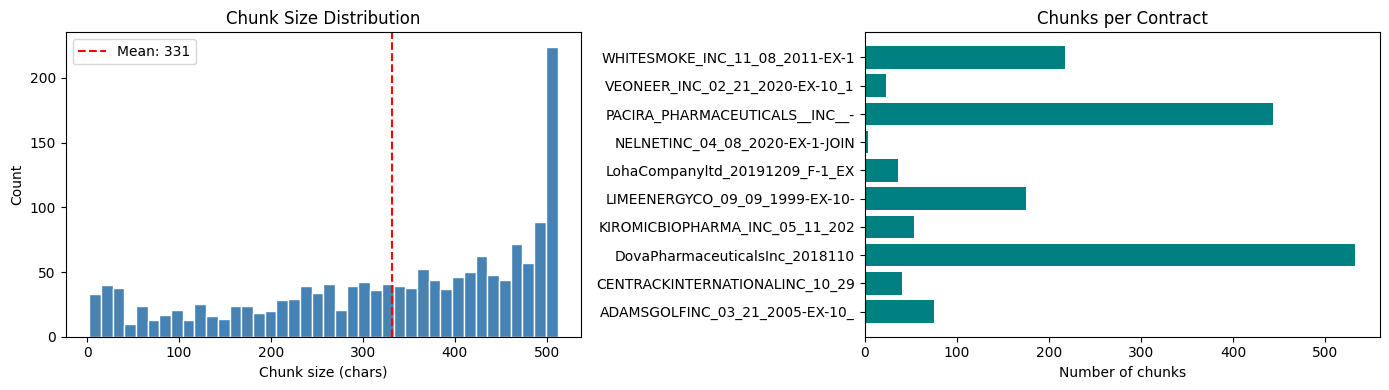

--- Sample chunk [0] ---
REDACTED COPY

CONFIDENTIAL TREATMENT REQUESTED

CONFIDENTIAL PORTIONS OF THIS

DOCUMENT HAVE BEEN REDACTED

AND HAVE BEEN SEPARATELY

FILED WITH THE COMMISSION

  1





ENDORSEMENT AGREEMENT

This Agreement is entered into on January 13, 2005 between professional golfer, TOM WATSON, (hereinafter referred to as "CONSULTANT") and ADAMS GOLF, LTD. (hereinafter referred to as "ADAMS GOLF").

WITNESSETH

--- Sample chunk [1] (notice the overlap with chunk 0) ---
WITNESSETH

WHEREAS, ADAMS GOLF desires to obtain the right to use the name, likeness and ENDORSEMENT of CONSULTANT in connection with the advertisement and promotion of ADAMS GOLF'S PRODUCT;

NOW THEREFORE, in consideration of the mutual covenants contained herein and other good and valuable consideration, the receipt and sufficiency of which is hereby acknowledged, the parties agree as follows:

CONTRACT PERIOD

1.   TERM OF CONTRACT


In [5]:
# Visualise chunk size distribution
import matplotlib.pyplot as plt
import numpy as np

sizes = [len(c.page_content) for c in chunks]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sizes, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Chunk size (chars)')
axes[0].set_ylabel('Count')
axes[0].set_title('Chunk Size Distribution')
axes[0].axvline(np.mean(sizes), color='red', linestyle='--', label=f'Mean: {np.mean(sizes):.0f}')
axes[0].legend()

# Chunks per contract
from collections import Counter
per_contract = Counter(c.metadata.get('source_file','?') for c in chunks)
names = [n[:30] for n in per_contract.keys()]
counts = list(per_contract.values())
axes[1].barh(names, counts, color='teal')
axes[1].set_xlabel('Number of chunks')
axes[1].set_title('Chunks per Contract')

plt.tight_layout()
plt.show()

# Show a sample chunk with overlap
print('--- Sample chunk [0] ---')
print(chunks[0].page_content)
print('\n--- Sample chunk [1] (notice the overlap with chunk 0) ---')
print(chunks[1].page_content)

## 4 — Embedding with `sentence-transformers/all-MiniLM-L6-v2`

**What is an embedding?**
An embedding is a dense numerical vector that captures the *semantic meaning* of a piece of text. Two sentences that mean the same thing will have vectors that are very close together in space — even if the actual words are different.

**Why `all-MiniLM-L6-v2`?**
- Only 22M parameters — runs fast on CPU too
- Produces 384-dimensional vectors
- Specifically trained on sentence-level similarity tasks
- Free and open source, no API key needed
- Performs well on legal and technical text

**Similarity metric:** We use **cosine similarity**. When a user queries *'What is the termination clause?'*, the query is also embedded, and we find the chunks whose vectors are closest to the query vector.

In [6]:
print('Loading embedding model (first run downloads ~22 MB)...')
embedding_model = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2',
    model_kwargs={'device': 'cpu'},  # or 'cuda' if you have GPU
    encode_kwargs={'normalize_embeddings': True},  # cosine similarity needs normalized vectors
)
print('Embedding model loaded!')

# Quick demo — embed two sentences and compare
from sklearn.metrics.pairwise import cosine_similarity

sent_a = 'Either party may terminate this agreement upon 30 days written notice.'
sent_b = 'This contract can be ended by either side with one month notice.'
sent_c = 'The distributor shall pay royalties quarterly.'

emb_a = embedding_model.embed_query(sent_a)
emb_b = embedding_model.embed_query(sent_b)
emb_c = embedding_model.embed_query(sent_c)

sim_ab = cosine_similarity([emb_a], [emb_b])[0][0]
sim_ac = cosine_similarity([emb_a], [emb_c])[0][0]

print(f'\nEmbedding vector size : {len(emb_a)}')
print(f'\nSemantic similarity (A vs B — same meaning, diff words) : {sim_ab:.4f}')
print(f'Semantic similarity (A vs C — different topic)          : {sim_ac:.4f}')
print('\nHigher similarity = same topic. The embeddings correctly identified this!')

Loading embedding model (first run downloads ~22 MB)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded!

Embedding vector size : 384

Semantic similarity (A vs B — same meaning, diff words) : 0.6776
Semantic similarity (A vs C — different topic)          : 0.3364

Higher similarity = same topic. The embeddings correctly identified this!


## 5 — Storing Vectors in ChromaDB

**What is a Vector Store?**
A vector store (or vector database) is a specialised database that stores embeddings and supports fast *nearest-neighbour search*. Given a query vector, it returns the `k` most similar stored vectors in milliseconds — even across millions of chunks.

**ChromaDB** is a lightweight, local, open-source vector store — perfect for development. We persist it to disk so it doesn't need to re-embed every time.

**The pipeline so far:**
```
PDF/DOCX/TXT → LangChain Loader → Documents → Splitter → Chunks → Embedding Model → ChromaDB
```

In [7]:
chroma_dir = '../data/chroma_db'
collection_name = 'cuad_contracts'

print(f'Building ChromaDB at: {os.path.abspath(chroma_dir)}')
print(f'Embedding {len(chunks)} chunks... (this takes ~30s)')

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    collection_name=collection_name,
    persist_directory=chroma_dir,
)

print(f'\nChromaDB built and persisted!')
print(f'Collection : {collection_name}')
print(f'Vectors stored : {vectorstore._collection.count()}')

Building ChromaDB at: c:\Users\Saahil Saitwal\OneDrive\Desktop\LegalEagle\data\chroma_db
Embedding 1602 chunks... (this takes ~30s)

ChromaDB built and persisted!
Collection : cuad_contracts
Vectors stored : 1602


## 6 — Semantic Retrieval: Finding Relevant Clauses

Now the pipeline is live. We can ask **natural language questions** about our contracts. The system embeds the query, searches ChromaDB for the nearest chunks, and returns the most relevant passages.

This is the **Retrieval** half of **RAG (Retrieval-Augmented Generation)**.

In [8]:
retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 4},  # return top 4 most relevant chunks
)

def query_contracts(question: str, k: int = 4):
    """Retrieve top-k most relevant contract chunks for a question."""
    print(f'QUERY: {question}')
    print('=' * 70)
    results = vectorstore.similarity_search_with_score(question, k=k)
    for i, (doc, score) in enumerate(results, 1):
        similarity = 1 - score  # Chroma returns distance; convert to similarity
        print(f'\n[Result {i}] Similarity: {similarity:.4f}')
        print(f'Source: {doc.metadata.get("source_file", "unknown")}')
        print(f'Text  : {doc.page_content[:400]}...')
        print('-' * 70)

# Test with real legal queries
query_contracts('What is the termination clause and notice period?')

QUERY: What is the termination clause and notice period?

[Result 1] Similarity: 0.4135
Source: DovaPharmaceuticalsInc_20181108_10-Q_EX-10_2_11414857_EX-10_.txt
Text  : 12.3 Other Early Termination.

12.3.1 Either Party shall have the right to terminate this Agreement before the end of the Term for its convenience upon [***] written notice to the other Party (and any such termination shall become effective at the end of such [***]); [***]....
----------------------------------------------------------------------

[Result 2] Similarity: 0.3841
Source: PACIRA_PHARMACEUTICALS__INC__-_A_R_STRATEGIC_LICENSING__DIST.txt
Text  : -53-

16. Termination   16.1 Prior Termination by Either Party. Either Party shall be entitled forthwith to terminate this Agreement by notice to the other if:...
----------------------------------------------------------------------

[Result 3] Similarity: 0.3729
Source: WHITESMOKE_INC_11_08_2011-EX-10_26-PROMOTION_AND_DISTRIBUTIO.txt
Text  : . Clauses 5.6 (Effect of

In [9]:
query_contracts('Who are the parties to the agreement?')

QUERY: Who are the parties to the agreement?

[Result 1] Similarity: 0.5223
Source: DovaPharmaceuticalsInc_20181108_10-Q_EX-10_2_11414857_EX-10_.txt
Text  : activities of the Parties contemplated by this Agreement....
----------------------------------------------------------------------

[Result 2] Similarity: 0.4217
Source: DovaPharmaceuticalsInc_20181108_10-Q_EX-10_2_11414857_EX-10_.txt
Text  : by this Agreement or otherwise agreed in writing by the Parties...
----------------------------------------------------------------------

[Result 3] Similarity: 0.2356
Source: DovaPharmaceuticalsInc_20181108_10-Q_EX-10_2_11414857_EX-10_.txt
Text  : . Each Party agrees that it shall cooperate fully with the other with respect to all disclosures regarding this Agreement to the Securities Exchange Commission and any other Governmental Authorities, including requests for confidential treatment of proprietary information of either Party included in any such disclosure...
-------------------------

In [10]:
query_contracts('What governing law applies to this contract?')

QUERY: What governing law applies to this contract?

[Result 1] Similarity: 0.2165
Source: DovaPharmaceuticalsInc_20181108_10-Q_EX-10_2_11414857_EX-10_.txt
Text  : 13.5 Governing Law. This Agreement and any and all matters arising directly or indirectly herefrom shall be governed by and construed and enforced in accordance with the internal laws of the [***] applicable to agreements made and to be performed entirely in such state, including its statutes of limitation but without giving effect to the conflict of law principles thereof.

13.6 Dispute Resolutio...
----------------------------------------------------------------------

[Result 2] Similarity: 0.1468
Source: WHITESMOKE_INC_11_08_2011-EX-10_26-PROMOTION_AND_DISTRIBUTIO.txt
Text  : 11.10 Governing Law. This Agreement is governed by English law and the parties submit to the exclusive jurisdiction of the English courts in  relation to any dispute (contractual or non-contractual) concerning this Agreement save that either party m

In [11]:
query_contracts('Are there any penalties or liquidated damages?')

QUERY: Are there any penalties or liquidated damages?

[Result 1] Similarity: 0.1683
Source: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR_AGREEMENT.txt
Text  : or  liquidated   damages   pertaining  to  late                   delivery unless Company  specifically  acknowledges and agrees                   in  writing  to the  same...
----------------------------------------------------------------------

[Result 2] Similarity: 0.1504
Source: PACIRA_PHARMACEUTICALS__INC__-_A_R_STRATEGIC_LICENSING__DIST.txt
Text  : .   10.10 Limitation of Damages...
----------------------------------------------------------------------

[Result 3] Similarity: 0.0046
Source: CENTRACKINTERNATIONALINC_10_29_1999-EX-10_3-WEB_SITE_HOSTING.txt
Text  : LIMITATION OF LIABILITY

i-on will not be liable under any circumstances for any lost profits or other consequential damages, even if i-on has been advised as to the possibility of such damages. i-on's liability for damages to the Customer for any cause whatsoever, 

## 7 — Full Pipeline: Function to Ingest Any New Contract

This wraps everything into a single reusable function.

In [12]:
def ingest_contract(file_path: str, vectorstore: Chroma) -> int:
    """
    Ingest a single new PDF/DOCX/TXT file into the existing ChromaDB.
    Returns the number of chunks added.
    """
    docs = load_document(file_path)
    for doc in docs:
        doc.metadata['source_file'] = Path(file_path).name
    chunks = splitter.split_documents(docs)
    vectorstore.add_documents(chunks)
    return len(chunks)


def search_contracts(question: str, vectorstore: Chroma, k: int = 3) -> list[dict]:
    """
    Search the vector store and return structured results.
    """
    results = vectorstore.similarity_search_with_score(question, k=k)
    output = []
    for doc, score in results:
        output.append({
            'source': doc.metadata.get('source_file', 'unknown'),
            'similarity': round(1 - score, 4),
            'text': doc.page_content,
        })
    return output


# Demo: search and display results nicely
results = search_contracts('exclusivity and non-compete restriction', vectorstore, k=3)
for r in results:
    print(f"Source     : {r['source']}")
    print(f"Similarity : {r['similarity']}")
    print(f"Text       : {r['text'][:300]}")
    print()

Source     : DovaPharmaceuticalsInc_20181108_10-Q_EX-10_2_11414857_EX-10_.txt
Similarity : 0.0457
Text       : 2.3.1 Non-Competition. (a) [***], neither Valeant nor its Affiliates shall, directly or indirectly, [***] in the Territory other than the Product; provided that if the Agreement is terminated by Dova pursuant to [***], then any Tail Period shall be immediately terminated if either Valeant or any of 

Source     : PACIRA_PHARMACEUTICALS__INC__-_A_R_STRATEGIC_LICENSING__DIST.txt
Similarity : 0.0386
Text       : .   4.16 Non-Compete. EKR shall not, during [**], market, distribute or sell a Competing Product in the Territory unless during such time an A/B  rated generic product of the Product(s) is launched in such country of the Territory or in the event this Agreement is terminated or EKR  exercises its ri

Source     : DovaPharmaceuticalsInc_20181108_10-Q_EX-10_2_11414857_EX-10_.txt
Similarity : 0.0013
Text       : 2.3 Non-Competition; Non-Solicitation.



## 8 — Pipeline Statistics & Summary

In [13]:
print('=' * 60)
print('  LEGALEAGLE RAG PIPELINE — SUMMARY')
print('=' * 60)
print(f'  Contracts ingested  : {len(raw_documents)}')
print(f'  Total chunks        : {len(chunks)}')
print(f'  Avg chunk size      : {sum(len(c.page_content) for c in chunks)//len(chunks)} chars')
print(f'  Embedding model     : sentence-transformers/all-MiniLM-L6-v2')
print(f'  Embedding dimension : 384')
print(f'  Vector store        : ChromaDB (local persistent)')
print(f'  Vectors in DB       : {vectorstore._collection.count()}')
print(f'  ChromaDB path       : {os.path.abspath(chroma_dir)}')
print('=' * 60)
print('  Pipeline ready! Use search_contracts() to query.')
print('=' * 60)

  LEGALEAGLE RAG PIPELINE — SUMMARY
  Contracts ingested  : 10
  Total chunks        : 1602
  Avg chunk size      : 331 chars
  Embedding model     : sentence-transformers/all-MiniLM-L6-v2
  Embedding dimension : 384
  Vector store        : ChromaDB (local persistent)
  Vectors in DB       : 1602
  ChromaDB path       : c:\Users\Saahil Saitwal\OneDrive\Desktop\LegalEagle\data\chroma_db
  Pipeline ready! Use search_contracts() to query.


---

**Next Steps:**
- Connect an LLM (e.g. Gemini or Mistral) to *generate* answers from retrieved chunks — completing the full **RAG** loop
- Add a Streamlit UI on top for interactive contract Q&A
- Scale to all 510 CUAD contracts